# Camera dei Deputati — XIX Legislature: Data Exploration

Exploring ~7M rows of roll-call voting data from the Italian parliament (Oct 2022 – Apr 2026).

**Prerequisites:** Run `python src/clean.py` first to generate the parquet files.

**Vote encoding:**
| Vote | Code |
|------|------|
| Favorevole | 1 |
| Contrario | -1 |
| Astensione | 0 |
| Non ha partecipato | 9 |
| In missione | 7 |
| Presidente di turno | 8 |
| Ha votato (secret ballot) | 6 |

## 1. Load Cleaned Data

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

PROCESSED_DIR = Path('data/processed')

df = pd.read_parquet(PROCESSED_DIR / 'votes_clean.parquet')
print(f'Loaded {len(df):,} rows from votes_clean.parquet')
df.head()

Loaded 6,904,915 rows from votes_clean.parquet


,legislature,session,vote_num,date,vote_type,title,description,deputy_name,group,vote,year_month,year,vote_code,voted,absent,on_mission,presiding,secret_ballot,vote_id
0,19,4,1,2022-10-25,Votazione per appello nominale n.1,NaN,"Mozione di fiducia Foti, Molinari, Cattaneo e ...",AIELLO DAVIDE,M5S,Contrario,2022-10,2022,-1,True,False,False,False,False,4_1
1,19,4,1,2022-10-25,Votazione per appello nominale n.1,NaN,"Mozione di fiducia Foti, Molinari, Cattaneo e ...",ALBANO LUCIA,FDI,Favorevole,2022-10,2022,1,True,False,False,False,False,4_1
2,19,4,1,2022-10-25,Votazione per appello nominale n.1,NaN,"Mozione di fiducia Foti, Molinari, Cattaneo e ...",ALIFANO ENRICA,M5S,Contrario,2022-10,2022,-1,True,False,False,False,False,4_1
3,19,4,1,2022-10-25,Votazione per appello nominale n.1,NaN,"Mozione di fiducia Foti, Molinari, Cattaneo e ...",ALMICI CRISTINA,FDI,Favorevole,2022-10,2022,1,True,False,False,False,False,4_1
4,19,4,1,2022-10-25,Votazione per appello nominale n.1,NaN,"Mozione di fiducia Foti, Molinari, Cattaneo e ...",AMATO GAETANO,M5S,Contrario,2022-10,2022,-1,True,False,False,False,False,4_1


In [ ]:
# Constants used throughout
MAJOR_GROUPS = ['FDI', 'PD-IDP', 'LEGA', 'M5S',
                'FI-PPE', 'AVS', 'NM-M-C', 'AZIONE-IV']
available_groups = [g for g in MAJOR_GROUPS if g in df['group'].unique()]
print(f'Major groups available: {available_groups}')

COALITION = ['FDI', 'LEGA', 'FI-PPE', 'NM-M-C']
OPPOSITION = ['PD-IDP', 'M5S', 'AVS']

PARTY_COLORS = {
    'FDI': '#003DA5',
    'PD-IDP': '#E2001A',
    'LEGA': '#008C45',
    'M5S': '#FFD700',
    'FI-PPE': '#0077CC',
    'AVS': '#6B8E23',
    'NM-M-C': '#9B59B6',
    'AZIONE-IV': '#FF6B35',
}

VOTE_COLORS = {
    'Favorevole': '#2ecc71',
    'Contrario': '#e74c3c',
    'Astensione': '#f39c12',
    'Non ha partecipato': '#95a5a6',
    'In missione': '#bdc3c7',
    'Presidente di turno': '#3498db',
    'Ha votato': '#8e44ad',
}

MIN_PARTICIPATION = 0.5  # 50% of party must vote for Rice calculation

# Convenience subsets
df_major = df[df['group'].isin(available_groups)].copy()
df_voted = df[df['voted']].copy()
df_voted_major = df_voted[df_voted['group'].isin(available_groups)].copy()

Major groups available: ['FDI', 'PD-IDP', 'LEGA', 'M5S', 'FI-PPE', 'AVS', 'NM-M-C']


## 2. Data Quality Checks

In [ ]:
# Sanity check: every row in exactly one category
check = df[['voted', 'absent', 'on_mission',
            'presiding', 'secret_ballot']].sum(axis=1)
unexpected = (check != 1).sum()
print(f'Rows not in exactly one category: {unexpected:,}')

print(f'\nBreakdown:')
print(f'  Voted (F/C/A):      {df["voted"].sum():>10,}')
print(f'  Absent (voluntary): {df["absent"].sum():>10,}')
print(f'  On mission:         {df["on_mission"].sum():>10,}')
print(f'  Presiding:          {df["presiding"].sum():>10,}')
print(f'  Secret ballot:      {df["secret_ballot"].sum():>10,}')
print(f'  Total:              {len(df):>10,}')

Rows not in exactly one category: 0

Breakdown:
  Voted (F/C/A):       4,598,223
  Absent (voluntary):  1,187,009
  On mission:          1,099,389
  Presiding:              17,020
  Secret ballot:           3,274
  Total:               6,904,915


In [ ]:
# Group consolidation summary
print('Group consolidation applied:')
for old_name in ['AIV-RE', 'APERRE', 'IVICRE', 'M-AVS', 'M-NM']:
    count = (df['group'].astype(str) == old_name).sum()
    new_name = df[df['group'].astype(
        str) == old_name]['group'].iloc[0] if count > 0 else '?'
    if count > 0:
        print(f'  {old_name:12s} -> {new_name:12s}  ({count:,} rows)')

print(f'\nConsolidated groups ({df["group"].nunique()}):')
print(df.groupby('group')['deputy_name'].nunique(
).sort_values(ascending=False).to_string())

Group consolidation applied:
  AIV-RE       -> AIV-RE        (86,814 rows)
  APERRE       -> APERRE        (144,133 rows)
  IVICRE       -> IVICRE        (98,507 rows)
  M-AVS        -> M-AVS         (12 rows)
  M-NM         -> M-NM          (9 rows)

Consolidated groups (16):
group
FDI       122
PD-IDP     75
LEGA       69
FI-PPE     55
M5S        54
AIV-RE     21
M-ALT      15
APERRE     13
AVS        12
M-AVS      12
NM-M-C     11
IVICRE      9
M-NM        9
------      7
M-MIN       4
M-+EUR      3


In [50]:
# Deputies who switched parties
deputy_groups = df.groupby('deputy_name')['group'].nunique()
switchers = deputy_groups[deputy_groups > 1]
print(f'Deputies who changed groups: {len(switchers)}')
print()
for name in switchers.index:
    groups = df[df['deputy_name'] == name].groupby('group').size()
    groups_str = ' -> '.join(f"{g} ({c})" for g, c in groups.items())
    print(f'  {name:35s} {groups_str}')

Deputies who changed groups: 62

  BELLOMO DAVIDE                      FI-PPE (4977) -> LEGA (12335)
  BENZONI FABRIZIO                    AIV-RE (4134) -> APERRE (13178)
  BERGAMINI DAVIDE                    FI-PPE (854) -> LEGA (16208) -> M-ALT (250)
  BICCHIELLI PINO                     FI-PPE (2790) -> M-NM (1) -> NM-M-C (14521)
  BONELLI ANGELO                      AVS (17311) -> M-AVS (1)
  BONETTI ELENA                       AIV-RE (4134) -> APERRE (13178)
  BONIFAZI FRANCESCO                  AIV-RE (4134) -> IVICRE (13178)
  BORRELLI FRANCESCO EMILIO           AVS (17311) -> M-AVS (1)
  BOSCAINI MARIA PAOLA                FI-PPE (9133) -> ------ (105)
  BOSCHI MARIA ELENA                  AIV-RE (4134) -> IVICRE (13178)
  BRAMBILLA MICHELA VITTORIA          M-ALT (983) -> NM-M-C (16329)
  CARFAGNA MARIA ROSARIA              AIV-RE (4134) -> M-ALT (449) -> NM-M-C (7281) -> APERRE (5448)
  CASTIGLIONE GIUSEPPE                AIV-RE (4134) -> FI-PPE (9845) -> APERRE (3333)
  CAVO

In [ ]:
# Vote type classification
print('Vote classification:')
final_votes = df[df["is_final_vote"]]["vote_id"].nunique(
) if "is_final_vote" in df.columns else 0
print(f'  Final votes:       {final_votes:>6,}')
confidence_votes = df[df["is_confidence"]]["vote_id"].nunique(
) if "is_confidence" in df.columns else 0
print(f'  Confidence votes:  {confidence_votes:>6,}')
amendment_votes = df[df["is_amendment"]]["vote_id"].nunique(
) if "is_amendment" in df.columns else 0
print(f'  Amendment votes:   {amendment_votes:>6,}')
odg_votes = df[df["is_odg"]]["vote_id"].nunique(
) if "is_odg" in df.columns else 0
print(f'  Ordini del giorno: {odg_votes:>6,}')
n_sub = df[df['is_substantive']]['vote_id'].nunique()
n_tot = df['vote_id'].nunique()
print(f'  Substantive total: {n_sub:>6,} / {n_tot:,} ({n_sub/n_tot*100:.1f}%)')

Vote classification:


KeyError: 'is_final_vote'

## 3. Overview Stats

In [ ]:
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f"Total rows:           {len(df):>12,}")
print(f"Roll-call votes:      {df['vote_id'].nunique():>12,}")
print(f"Sessions:             {df['session'].nunique():>12,}")
print(f"Deputies:             {df['deputy_name'].nunique():>12,}")
print(f"Groups (consolidated):{df['group'].nunique():>12,}")
print(
    f"Date range:           {df['date'].min().strftime('%d/%m/%Y')} — {df['date'].max().strftime('%d/%m/%Y')}")

DATASET OVERVIEW
Total rows:              6,904,915
Roll-call votes:            17,312
Sessions:                      375
Deputies:                      413
Groups (consolidated):          16
Date range:           25/10/2022 — 01/04/2026


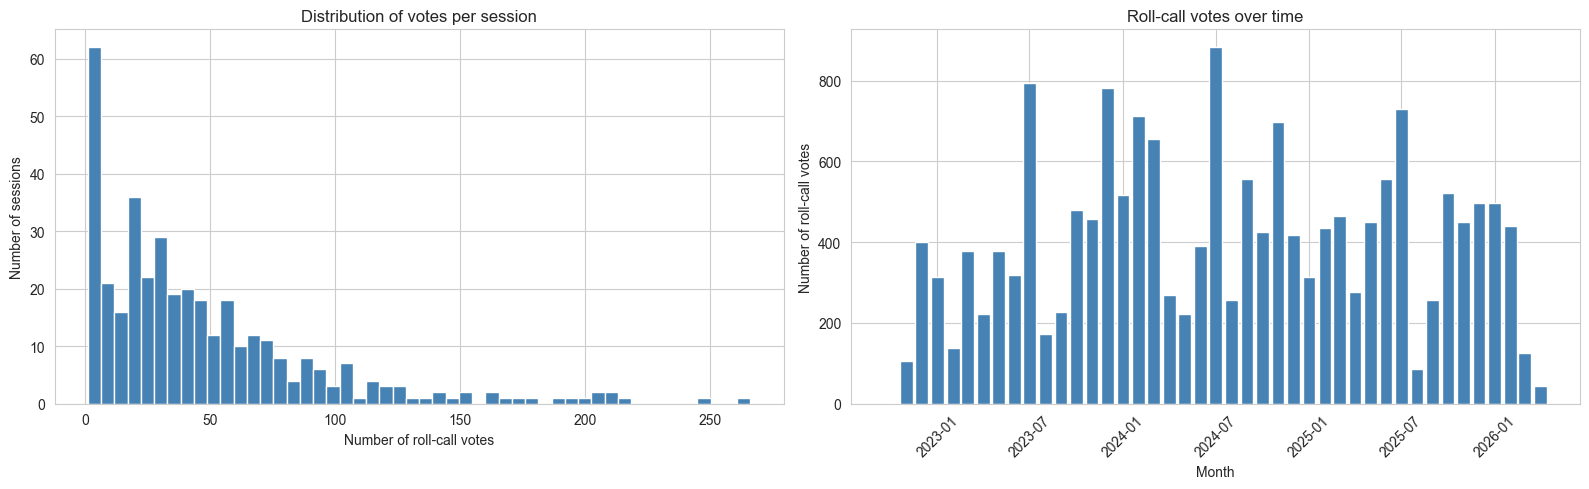

In [ ]:
# Votes per session + votes over time
votes_per_session = df.groupby('session')['vote_num'].max()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(votes_per_session, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of roll-call votes')
axes[0].set_ylabel('Number of sessions')
axes[0].set_title('Distribution of votes per session')

votes_per_month = df.groupby('year_month')['vote_id'].nunique()
votes_per_month.index = votes_per_month.index.to_timestamp()
axes[1].bar(votes_per_month.index, votes_per_month.values,
            width=25, color='steelblue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of roll-call votes')
axes[1].set_title('Roll-call votes over time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

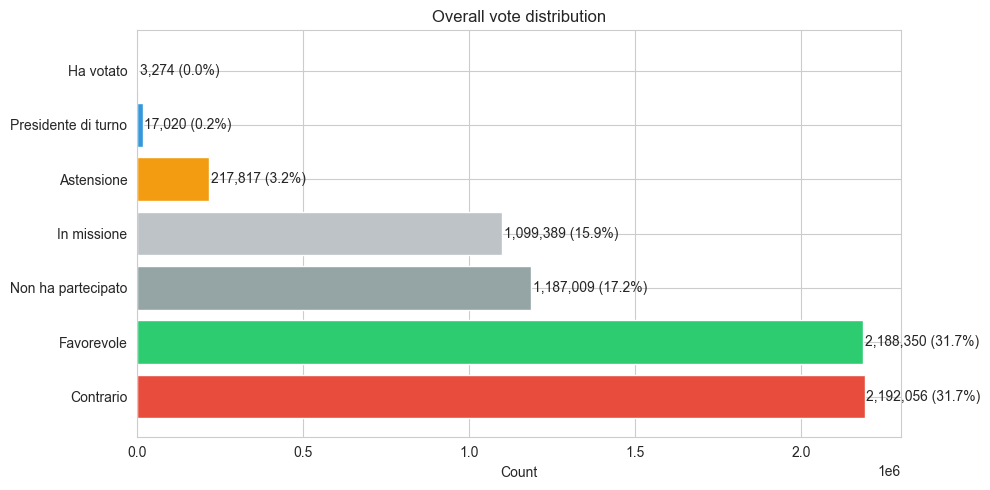

In [55]:
# Overall vote distribution
vote_counts = df['vote'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(vote_counts.index, vote_counts.values,
               color=[VOTE_COLORS.get(v, '#999') for v in vote_counts.index])
for bar, val in zip(bars, vote_counts.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center')
ax.set_xlabel('Count')
ax.set_title('Overall vote distribution')
plt.tight_layout()
plt.show()

## 4. Party-level Analysis

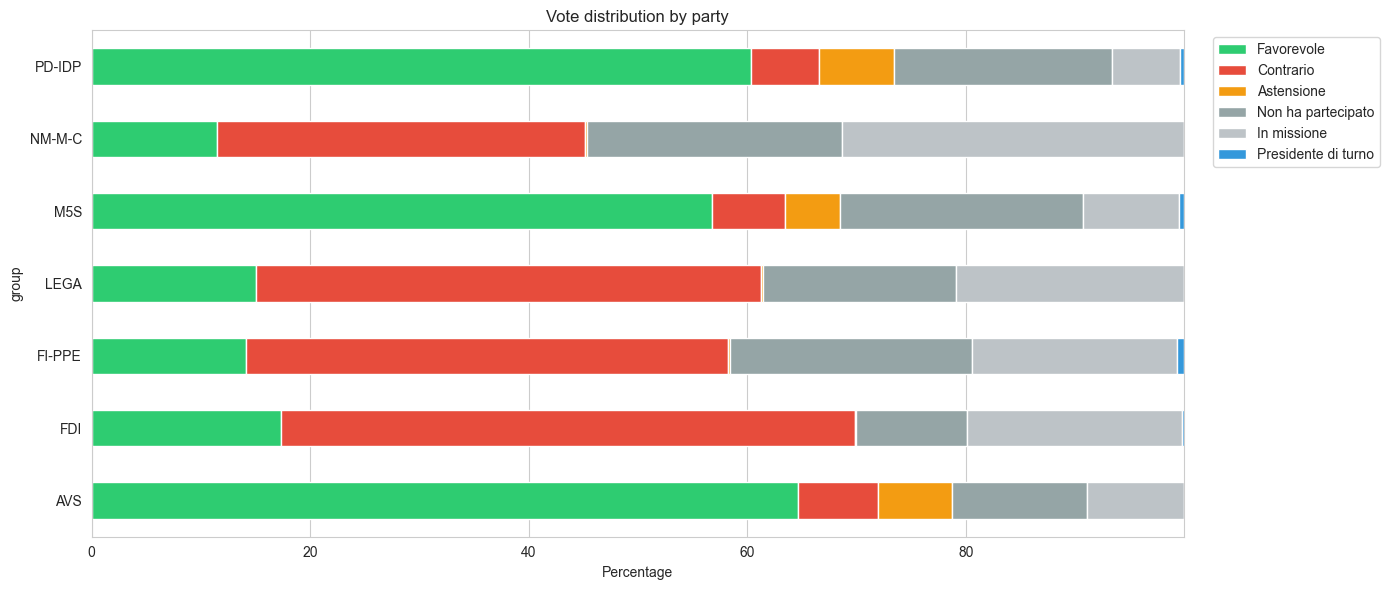

In [ ]:
# Vote distribution by party
party_vote_pct = (
    df_major.groupby(['group', 'vote']).size()
    .unstack(fill_value=0)
)
party_vote_pct = party_vote_pct.div(party_vote_pct.sum(axis=1), axis=0) * 100

col_order = ['Favorevole', 'Contrario', 'Astensione',
             'Non ha partecipato', 'In missione', 'Presidente di turno']
col_order = [c for c in col_order if c in party_vote_pct.columns]
party_vote_pct = party_vote_pct[col_order]

fig, ax = plt.subplots(figsize=(14, 6))
party_vote_pct.plot(kind='barh', stacked=True, ax=ax,
                    color=[VOTE_COLORS.get(c, '#999') for c in col_order])
ax.set_xlabel('Percentage')
ax.set_title('Vote distribution by party')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Rice Cohesion Index with minimum participation threshold

def rice_index(group_votes):
    n = len(group_votes)
    if n == 0:
        return np.nan
    n_yes = (group_votes == 1).sum()
    n_no = (group_votes == -1).sum()
    return abs(n_yes - n_no) / n


# Party size per vote (all deputies listed, not just those who voted)
party_size = df_major.groupby(
    ['group', 'vote_id']).size().reset_index(name='party_total')
party_voted_count = df_voted_major.groupby(
    ['group', 'vote_id']).size().reset_index(name='n_voted')

party_part = party_size.merge(
    party_voted_count, on=['group', 'vote_id'], how='left')
party_part['n_voted'] = party_part['n_voted'].fillna(0)
party_part['pct_voted'] = party_part['n_voted'] / party_part['party_total']

# Keep only party-vote combos meeting threshold
valid_pv = party_part[party_part['pct_voted']
                      >= MIN_PARTICIPATION][['group', 'vote_id']]

print(f'Participation threshold: {MIN_PARTICIPATION:.0%}')
print(f'Party-vote combos: {len(party_part):,} -> {len(valid_pv):,} '
      f'(removed {len(party_part)-len(valid_pv):,}, {(len(party_part)-len(valid_pv))/len(party_part)*100:.1f}%)')

# Calculate Rice on valid combos only
df_voted_valid = df_voted_major.merge(
    valid_pv, on=['group', 'vote_id'], how='inner')

rice_by_pv = (
    df_voted_valid.groupby(['group', 'vote_id'])['vote_code']
    .apply(rice_index).reset_index().rename(columns={'vote_code': 'rice'})
)

rice_avg = rice_by_pv.groupby(
    'group')['rice'].mean().sort_values(ascending=False)

print(
    f'\nAverage Rice Cohesion Index (min {MIN_PARTICIPATION:.0%} participation):')
print('(1.0 = unified, 0.0 = split)')
print()
for group, val in rice_avg.items():
    bar = '█' * int(val * 40)
    print(f'  {group:12s} {val:.3f}  {bar}')

Participation threshold: 50%
Party-vote combos: 121,182 -> 107,620 (removed 13,562, 11.2%)

Average Rice Cohesion Index (min 50% participation):
(1.0 = unified, 0.0 = split)

  FDI          0.997  ███████████████████████████████████████
  LEGA         0.989  ███████████████████████████████████████
  NM-M-C       0.985  ███████████████████████████████████████
  FI-PPE       0.981  ███████████████████████████████████████
  M5S          0.924  ████████████████████████████████████
  AVS          0.913  ████████████████████████████████████
  PD-IDP       0.907  ████████████████████████████████████


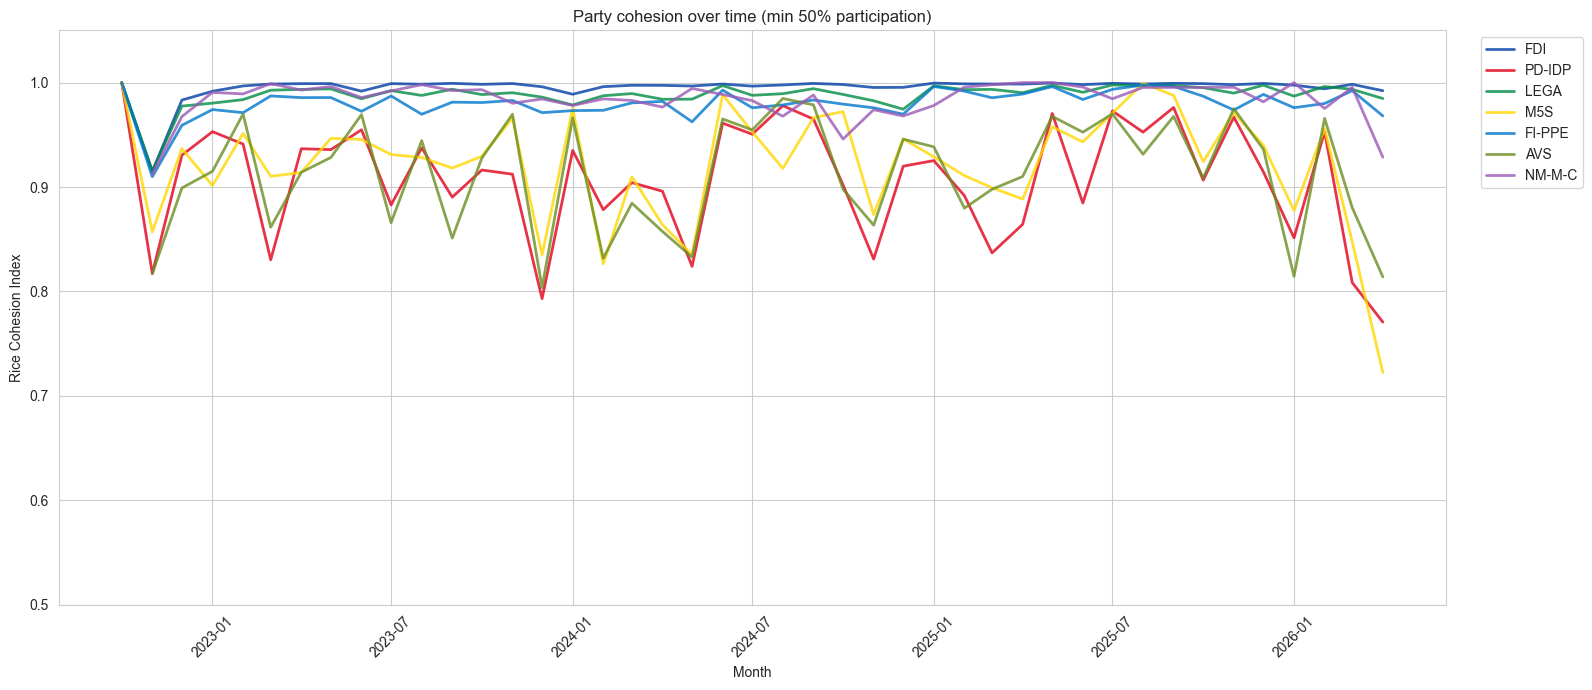

In [ ]:
# Rice index over time
df_vv_dated = df_voted_valid.dropna(subset=['date']).copy()
df_vv_dated['year_month'] = df_vv_dated['date'].dt.to_period('M')

rice_monthly = (
    df_vv_dated.groupby(['group', 'year_month', 'vote_id'])['vote_code']
    .apply(rice_index).reset_index().rename(columns={'vote_code': 'rice'})
)
rice_monthly_avg = rice_monthly.groupby(['group', 'year_month'])[
    'rice'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 7))
for group in available_groups:
    s = rice_monthly_avg[rice_monthly_avg['group'] == group]
    if len(s) == 0:
        continue
    ax.plot(s['year_month'].dt.to_timestamp(), s['rice'],
            label=group, color=PARTY_COLORS.get(group, '#999'), linewidth=2, alpha=0.8)

ax.set_xlabel('Month')
ax.set_ylabel('Rice Cohesion Index')
ax.set_title(
    f'Party cohesion over time (min {MIN_PARTICIPATION:.0%} participation)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0.5, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Most divided votes per party (with participation context)
print(
    f'Most divided votes per party (min {MIN_PARTICIPATION:.0%} participation):')
print('=' * 90)

for group in available_groups:
    subset = rice_by_pv[rice_by_pv['group'] == group]
    worst = subset.nsmallest(5, 'rice')
    print(f'\n{group}:')
    for _, row in worst.iterrows():
        vr = df[df['vote_id'] == row['vote_id']]
        vi = vr.iloc[0]
        pr = vr[vr['group'] == group]
        n_v = pr['voted'].sum()
        n_t = len(pr)
        desc = vi.get('description', '') or vi.get('title', '')
        desc = desc[:70] if isinstance(desc, str) else ''
        d = vi['date'].strftime('%d/%m/%Y') if pd.notna(vi['date']) else '?'
        print(f"  Rice={row['rice']:.3f} | {d} | {n_v}/{n_t} voted | {desc}")

Most divided votes per party (min 50% participation):

FDI:
  Rice=0.000 | 29/06/2023 | 91/118 voted | Ordine del giorno n. 9/1238/114 GRIMALDI MARCO (AVS)
  Rice=0.000 | 23/11/2022 | 94/118 voted | Mozione n. 1-00004 ASCARI STEFANIA (M5S) ed altri
  Rice=0.000 | 30/11/2022 | 94/118 voted | Mozione n. 1-00025, limitatamente alla premessa, SERRACCHIANI DEBORA (
  Rice=0.000 | 30/11/2022 | 94/118 voted | Mozione n. 1-00022, limitatamente alla parte dispositiva, ad eccezione
  Rice=0.000 | 30/11/2022 | 95/118 voted | Mozione n. 1-00022, limitatamente al capoverso primo della parte dispo

PD-IDP:
  Rice=0.000 | 09/05/2023 | 57/69 voted | Mozione n. 1-00083 (Ulteriore nuova formulazione), capoverso terzo del
  Rice=0.000 | 09/05/2023 | 55/69 voted | Mozione n. 1-00083 (Ulteriore nuova formulazione), capoverso quarto de
  Rice=0.000 | 09/05/2023 | 56/69 voted | Mozione n. 1-00083 (Ulteriore nuova formulazione), capoverso ottavo de
  Rice=0.000 | 09/05/2023 | 56/69 voted | Mozione n. 1-00083 

In [63]:
# Cohesion: substantive votes vs all votes
df_sub_valid = df_voted_valid[df_voted_valid['is_substantive']].copy()

rice_sub = (
    df_sub_valid.groupby(['group', 'vote_id'])['vote_code']
    .apply(rice_index).reset_index().rename(columns={'vote_code': 'rice'})
)
rice_sub_avg = rice_sub.groupby('group')['rice'].mean()

print(f"{'Party':12s} {'All votes':>10s} {'Substantive':>12s} {'Diff':>8s}")
print('-' * 45)
for group in available_groups:
    a = rice_avg.get(group, np.nan)
    s = rice_sub_avg.get(group, np.nan)
    d = s - a if not (np.isnan(a) or np.isnan(s)) else np.nan
    print(f'  {group:12s} {a:8.3f}   {s:10.3f}  {d:+7.3f}')

KeyError: 'is_substantive'

## 5. Attendance Analysis

In [ ]:
# Attendance rate by party
attendance = (
    df_major.groupby('group_clean')
    .agg(total=('vote_code', 'count'), voted=('voted', 'sum'),
         absent=('absent', 'sum'), on_mission=('on_mission', 'sum'))
)
attendance['attendance_pct'] = attendance['voted'] / attendance['total'] * 100
attendance['absent_pct'] = attendance['absent'] / attendance['total'] * 100
attendance['mission_pct'] = attendance['on_mission'] / \
    attendance['total'] * 100

print('Attendance rates by party:')
print(attendance[['attendance_pct', 'absent_pct', 'mission_pct']]
      .round(1).sort_values('attendance_pct', ascending=False).to_string())

KeyError: 'group_clean'

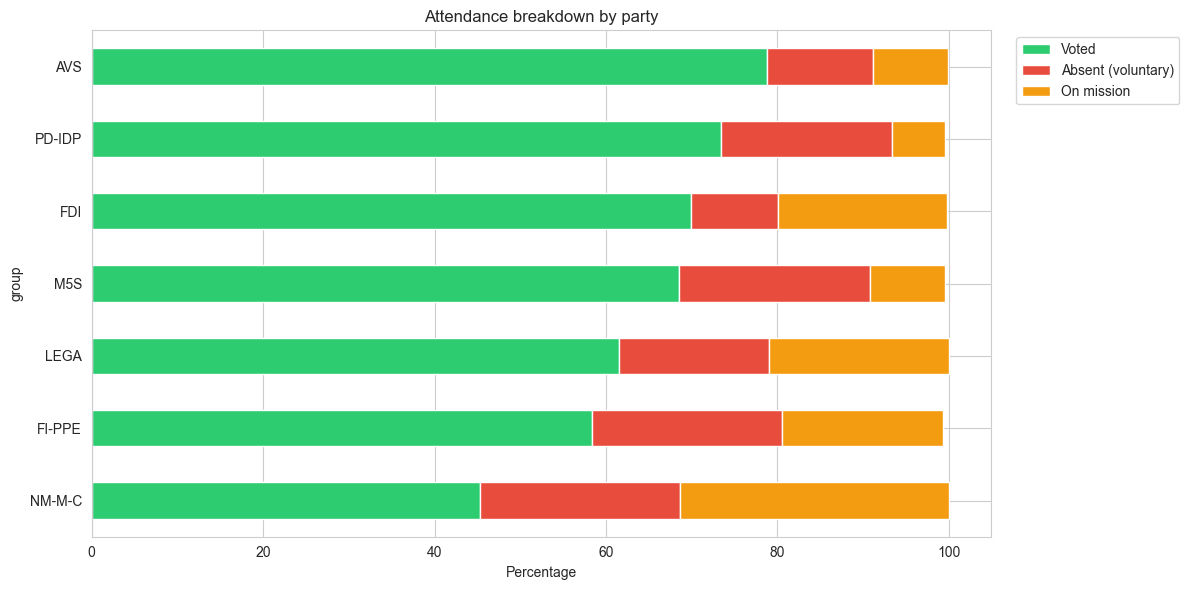

In [ ]:
# Attendance breakdown — visual
att_plot = attendance[['attendance_pct', 'absent_pct',
                       'mission_pct']].sort_values('attendance_pct')

fig, ax = plt.subplots(figsize=(12, 6))
att_plot.plot(kind='barh', stacked=True, ax=ax,
              color=['#2ecc71', '#e74c3c', '#f39c12'])
ax.set_xlabel('Percentage')
ax.set_title('Attendance breakdown by party')
ax.legend(['Voted', 'Absent (voluntary)', 'On mission'],
          bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

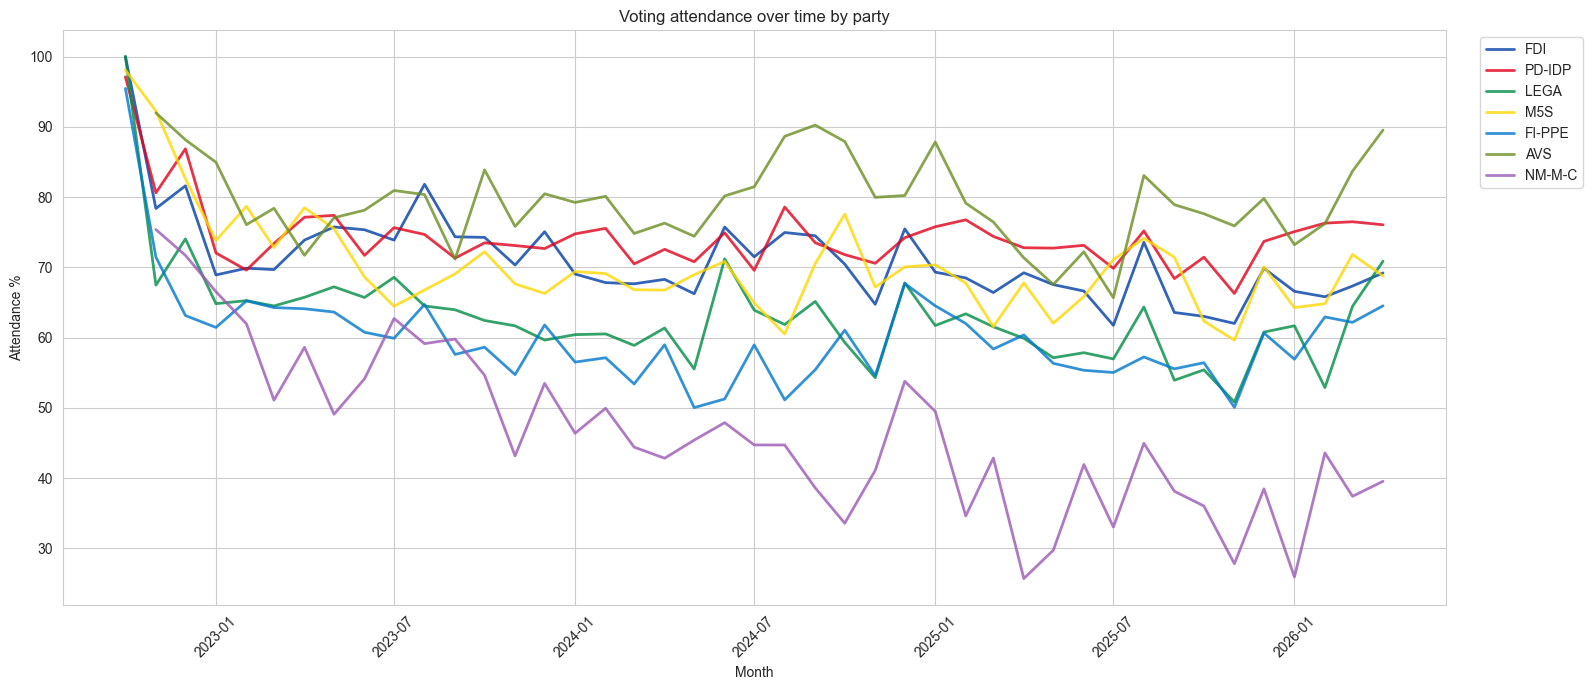

In [68]:
# Attendance over time
df_maj_dated = df_major.dropna(subset=['date']).copy()
df_maj_dated['year_month'] = df_maj_dated['date'].dt.to_period('M')

att_monthly = (
    df_maj_dated.groupby(['group', 'year_month'])
    .agg(total=('vote_code', 'count'), voted=('voted', 'sum')).reset_index()
)
att_monthly['pct'] = att_monthly['voted'] / att_monthly['total'] * 100

fig, ax = plt.subplots(figsize=(16, 7))
for group in available_groups:
    s = att_monthly[att_monthly['group'] == group]
    ax.plot(s['year_month'].dt.to_timestamp(), s['pct'],
            label=group, color=PARTY_COLORS.get(group, '#999'), linewidth=2, alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Attendance %')
ax.set_title('Voting attendance over time by party')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# Most absent deputies
dep_att = (
    df.groupby(['deputy_name', 'group'])
    .agg(total=('vote_code', 'count'), voted=('voted', 'sum'), absent=('absent', 'sum'))
    .reset_index()
)
dep_att['absent_pct'] = dep_att['absent'] / dep_att['total'] * 100
dep_att['attendance_pct'] = dep_att['voted'] / dep_att['total'] * 100

min_votes = dep_att['total'].quantile(0.25)
da_f = dep_att[dep_att['total'] >= min_votes]

print(f'Top 20 most absent deputies (min {min_votes:.0f} vote opportunities):')
print()
for _, r in da_f.nlargest(20, 'absent_pct').iterrows():
    print(f"  {r['deputy_name']:35s} {r['group']:12s} "
          f"Absent: {r['absent_pct']:5.1f}%  Voted: {r['attendance_pct']:5.1f}%  ({r['total']:.0f} votes)")

Top 20 most absent deputies (min 13178 vote opportunities):

  BOSSI UMBERTO                       LEGA         Absent: 100.0%  Voted:   0.0%  (17209 votes)
  ANGELUCCI ANTONIO                   LEGA         Absent:  99.9%  Voted:   0.1%  (17312 votes)
  FASCINA MARTA ANTONIA               FI-PPE       Absent:  89.4%  Voted:  10.6%  (17312 votes)
  CONTE GIUSEPPE                      M5S          Absent:  82.4%  Voted:  17.5%  (17312 votes)
  SCHLEIN ELLY                        PD-IDP       Absent:  80.0%  Voted:  20.0%  (17312 votes)
  SUDANO VALERIA                      LEGA         Absent:  75.6%  Voted:  12.4%  (17312 votes)
  BONIFAZI FRANCESCO                  IVICRE       Absent:  57.7%  Voted:  42.3%  (13178 votes)
  ORSINI ANDREA                       FI-PPE       Absent:  57.0%  Voted:  23.5%  (17312 votes)
  TIRELLI FRANCO                      NM-M-C       Absent:  55.2%  Voted:  43.3%  (17311 votes)
  MANCINI CLAUDIO                     PD-IDP       Absent:  53.8%  Voted:  

In [ ]:
# Attendance: final votes vs amendment votes
att_by_type = (
    df_major.assign(is_final=df_major['is_final_vote'])
    .groupby(['group', 'is_final'])
    .agg(total=('vote_code', 'count'), voted=('voted', 'sum')).reset_index()
)
att_by_type['pct'] = att_by_type['voted'] / att_by_type['total'] * 100
att_by_type['label'] = att_by_type['is_final'].map(
    {True: 'Final votes', False: 'Amendment votes'})

fig, ax = plt.subplots(figsize=(12, 6))
pivot = att_by_type.pivot(index='group', columns='label', values='pct')
pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_ylabel('Attendance %')
ax.set_title('Attendance: final votes vs amendment votes')
ax.legend(bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'is_final_vote'

## 6. Defection Analysis

In [ ]:
# Party majority per vote (using group_clean and per-vote group assignment)
df_voted_only = df[df['voted']].copy()

party_majority = (
    df_voted_only.groupby(['group', 'vote_id'])['vote_code']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else np.nan)
    .reset_index().rename(columns={'vote_code': 'party_line'})
)

df_def = df_voted_only.merge(
    party_majority, on=['group', 'vote_id'], how='left')
df_def['defected'] = df_def['vote_code'] != df_def['party_line']

print(f"Total votes cast: {len(df_def):,}")
print(f"Total defections: {df_def['defected'].sum():,}")
print(f"Overall defection rate: {df_def['defected'].mean()*100:.2f}%")

Total votes cast: 4,598,223
Total defections: 35,945
Overall defection rate: 0.78%


In [ ]:
# Defection rate by party
pd_clean = (
    df_def[df_def['group'].isin(available_groups)]
    .groupby('group')
    .agg(total_votes=('defected', 'count'), defections=('defected', 'sum'))
    .reset_index()
)
pd_clean['defection_pct'] = pd_clean['defections'] / \
    pd_clean['total_votes'] * 100
pd_clean = pd_clean.sort_values('defection_pct', ascending=False)

print('Defection rate by party (consolidated groups):')
for _, r in pd_clean.iterrows():
    bar = '█' * int(r['defection_pct'] * 2)
    print(f"  {r['group']:12s} {r['defection_pct']:5.2f}%  {bar}")

Defection rate by party (consolidated groups):
  FI-PPE        0.94%  █
  NM-M-C        0.72%  █
  LEGA          0.55%  █
  AVS           0.34%  
  PD-IDP        0.30%  
  M5S           0.25%  
  FDI           0.12%  


In [76]:
# Top defectors
dd = (
    df_def[df_def['group'].isin(available_groups)]
    .groupby(['deputy_name', 'group'])
    .agg(total_votes=('defected', 'count'), defections=('defected', 'sum'))
    .reset_index()
)
dd['defection_pct'] = dd['defections'] / dd['total_votes'] * 100
dd_f = dd[dd['total_votes'] >= 500]

print(f'Top 25 defectors in major parties (min 500 votes):')
print()
for _, r in dd_f.nlargest(25, 'defection_pct').iterrows():
    print(f"  {r['deputy_name']:35s} {r['group']:12s} "
          f"Defection: {r['defection_pct']:5.1f}%  ({r['defections']:.0f}/{r['total_votes']:.0f})")

Top 25 defectors in major parties (min 500 votes):

  CANNIZZARO FRANCESCO                FI-PPE       Defection:   5.0%  (413/8267)
  COMAROLI SILVANA ANDREINA           LEGA         Defection:   4.6%  (735/16077)
  POLIDORI CATIA                      FI-PPE       Defection:   3.2%  (134/4241)
  NEVI RAFFAELE                       FI-PPE       Defection:   2.7%  (338/12685)
  BELLOMO DAVIDE                      FI-PPE       Defection:   2.2%  (86/3868)
  ORSINI ANDREA                       FI-PPE       Defection:   2.1%  (84/4069)
  MARROCCO PATRIZIA                   FI-PPE       Defection:   2.0%  (265/12954)
  CAROPPO ANDREA                      FI-PPE       Defection:   1.9%  (304/16054)
  BRAMBILLA MICHELA VITTORIA          NM-M-C       Defection:   1.9%  (32/1717)
  SORTE ALESSANDRO                    FI-PPE       Defection:   1.9%  (243/13053)
  COSTA ENRICO                        FI-PPE       Defection:   1.8%  (105/5783)
  TIRELLI FRANCO                      NM-M-C       Defe

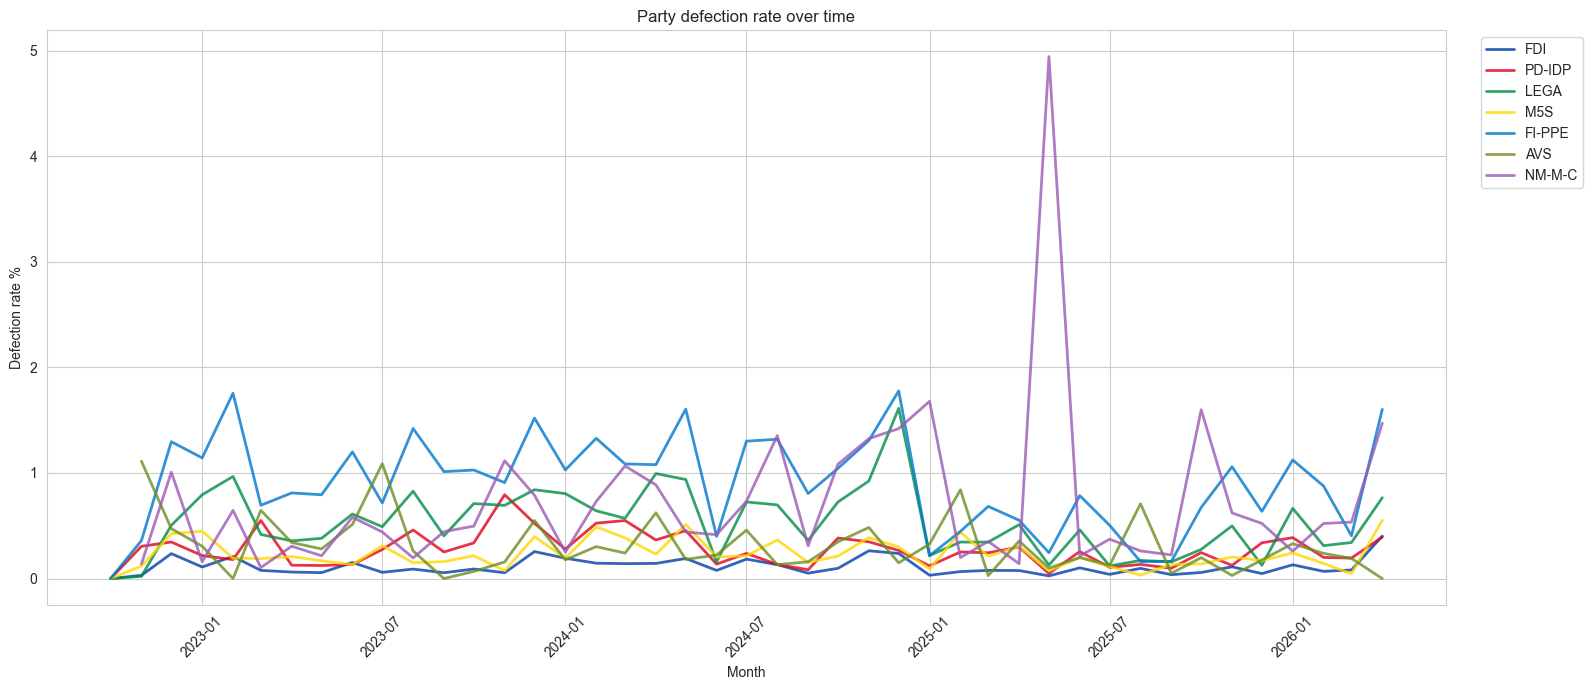

In [ ]:
# Defection over time
df_def_dated = df_def.dropna(subset=['date']).copy()
df_def_dated['year_month'] = df_def_dated['date'].dt.to_period('M')

def_monthly = (
    df_def_dated[df_def_dated['group'].isin(available_groups)]
    .groupby(['group', 'year_month'])
    .agg(total=('defected', 'count'), defections=('defected', 'sum')).reset_index()
)
def_monthly['pct'] = def_monthly['defections'] / def_monthly['total'] * 100

fig, ax = plt.subplots(figsize=(16, 7))
for group in available_groups:
    s = def_monthly[def_monthly['group'] == group]
    if len(s) == 0:
        continue
    ax.plot(s['year_month'].dt.to_timestamp(), s['pct'],
            label=group, color=PARTY_COLORS.get(group, '#999'), linewidth=2, alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Defection rate %')
ax.set_title('Party defection rate over time')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Deputy Similarity

In [79]:
# Load precomputed matrices
vote_matrix = pd.read_parquet(PROCESSED_DIR / 'vote_matrix.parquet')
similarity = pd.read_parquet(PROCESSED_DIR / 'similarity_matrix.parquet')
deputies_df = pd.read_parquet(PROCESSED_DIR / 'deputies.parquet')

deputy_group = dict(zip(deputies_df['deputy_name'], deputies_df['group']))

print(f'Vote matrix: {vote_matrix.shape}')
print(f'Similarity matrix: {similarity.shape}')
print(f'Deputies: {len(deputies_df)}')

Vote matrix: (413, 17309)
Similarity matrix: (413, 413)
Deputies: 413


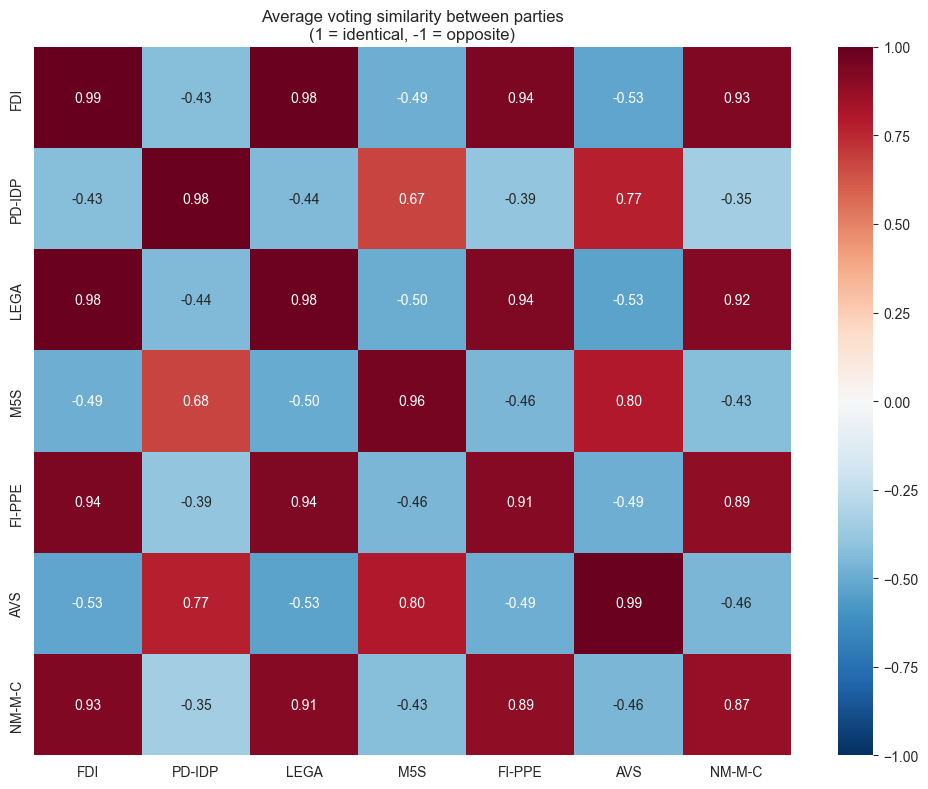

In [ ]:
# Party-level similarity heatmap
major_deps = [d for d in similarity.index if deputy_group.get(
    d) in available_groups]
sim_major = similarity.loc[major_deps, major_deps]

party_sim = pd.DataFrame(index=available_groups,
                         columns=available_groups, dtype=float)
for g1 in available_groups:
    d1 = [d for d in major_deps if deputy_group[d] == g1]
    for g2 in available_groups:
        d2 = [d for d in major_deps if deputy_group[d] == g2]
        if d1 and d2:
            party_sim.loc[g1, g2] = sim_major.loc[d1, d2].mean().mean()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(party_sim.astype(float), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title(
    'Average voting similarity between parties\n(1 = identical, -1 = opposite)')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-party allies and opposites
pairs = []
dep_list = similarity.index.tolist()
for i in range(len(dep_list)):
    for j in range(i+1, len(dep_list)):
        d1, d2 = dep_list[i], dep_list[j]
        g1, g2 = deputy_group.get(d1), deputy_group.get(d2)
        if g1 and g2 and g1 != g2 and g1 in available_groups and g2 in available_groups:
            pairs.append({'dep1': d1, 'g1': g1, 'dep2': d2, 'g2': g2,
                          'sim': similarity.loc[d1, d2]})

pairs_df = pd.DataFrame(pairs)

print('Top 15 cross-party allies (highest similarity):')
for _, r in pairs_df.nlargest(15, 'sim').iterrows():
    print(
        f"  {r['dep1']:25s} ({r['g1']:8s}) <-> {r['dep2']:25s} ({r['g2']:8s})  sim={r['sim']:.3f}")

print('\nTop 15 cross-party opposites (lowest similarity):')
for _, r in pairs_df.nsmallest(15, 'sim').iterrows():
    print(
        f"  {r['dep1']:25s} ({r['g1']:8s}) <-> {r['dep2']:25s} ({r['g2']:8s})  sim={r['sim']:.3f}")

Top 15 cross-party allies (highest similarity):
  ALBANO LUCIA              (FDI     ) <-> ANGELUCCI ANTONIO         (LEGA    )  sim=1.000
  ALBANO LUCIA              (FDI     ) <-> FRENI FEDERICO            (LEGA    )  sim=1.000
  ALBANO LUCIA              (FDI     ) <-> RIXI EDOARDO              (LEGA    )  sim=1.000
  ALMICI CRISTINA           (FDI     ) <-> ANGELUCCI ANTONIO         (LEGA    )  sim=1.000
  ALMICI CRISTINA           (FDI     ) <-> BOSSI UMBERTO             (LEGA    )  sim=1.000
  ALMICI CRISTINA           (FDI     ) <-> DI RUBBA ALBERTO          (LEGA    )  sim=1.000
  ALMICI CRISTINA           (FDI     ) <-> MAFFIOLI MANUELA          (LEGA    )  sim=1.000
  AMBROSI ALESSIA           (FDI     ) <-> ANGELUCCI ANTONIO         (LEGA    )  sim=1.000
  AMBROSI ALESSIA           (FDI     ) <-> BOSSI UMBERTO             (LEGA    )  sim=1.000
  AMBROSI ALESSIA           (FDI     ) <-> DI RUBBA ALBERTO          (LEGA    )  sim=1.000
  AMBROSI ALESSIA           (FDI     ) <->

## 8. Coalition vs Opposition

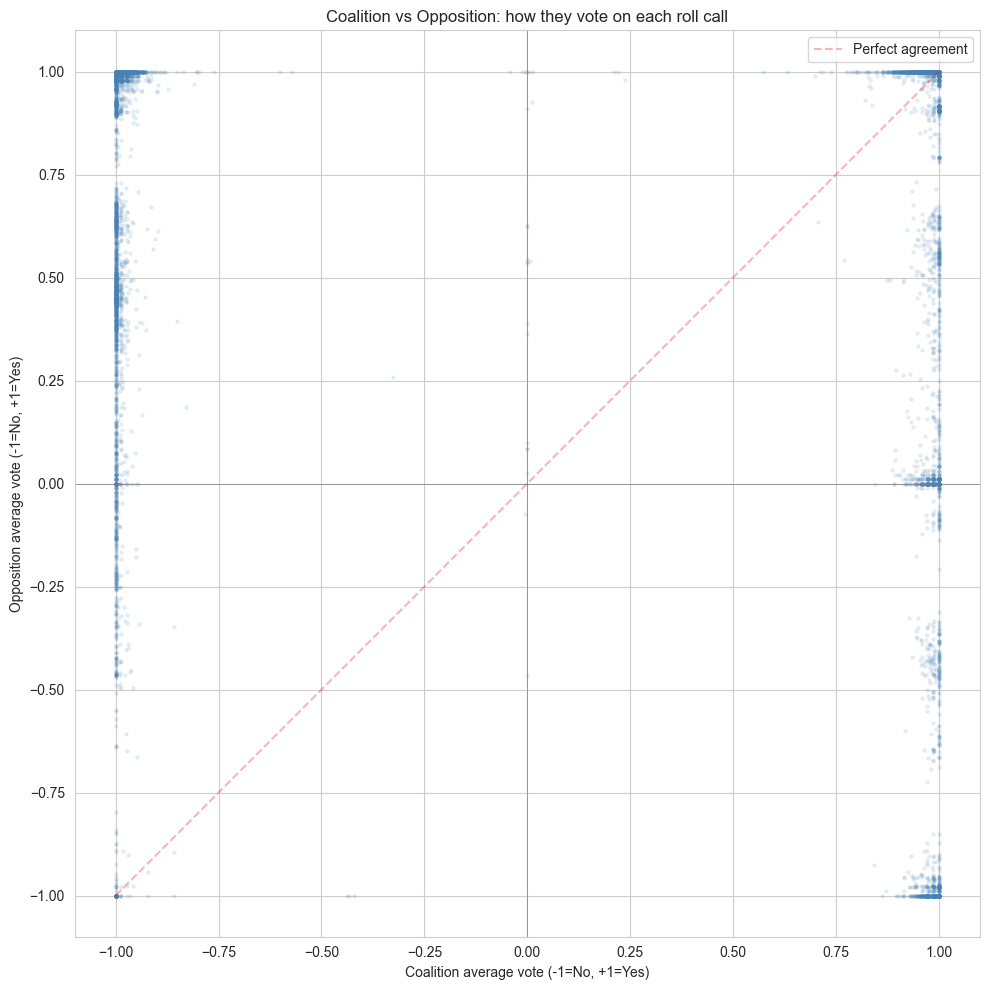

In [ ]:
# Coalition vs Opposition scatter
coal_groups = [g for g in COALITION if g in available_groups]
opp_groups = [g for g in OPPOSITION if g in available_groups]

df_vm = df_voted[df_voted['group'].isin(available_groups)].copy()
df_vm['side'] = df_vm['group'].apply(
    lambda g: 'Coalition' if g in coal_groups else 'Opposition' if g in opp_groups else 'Other'
)
df_vm = df_vm[df_vm['side'] != 'Other']

side_avg = df_vm.groupby(['side', 'vote_id'])[
    'vote_code'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(side_avg['Coalition'], side_avg['Opposition'],
           alpha=0.1, s=5, color='steelblue')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.3, label='Perfect agreement')
ax.set_xlabel('Coalition average vote (-1=No, +1=Yes)')
ax.set_ylabel('Opposition average vote (-1=No, +1=Yes)')
ax.set_title('Coalition vs Opposition: how they vote on each roll call')
ax.legend()
plt.tight_layout()
plt.show()

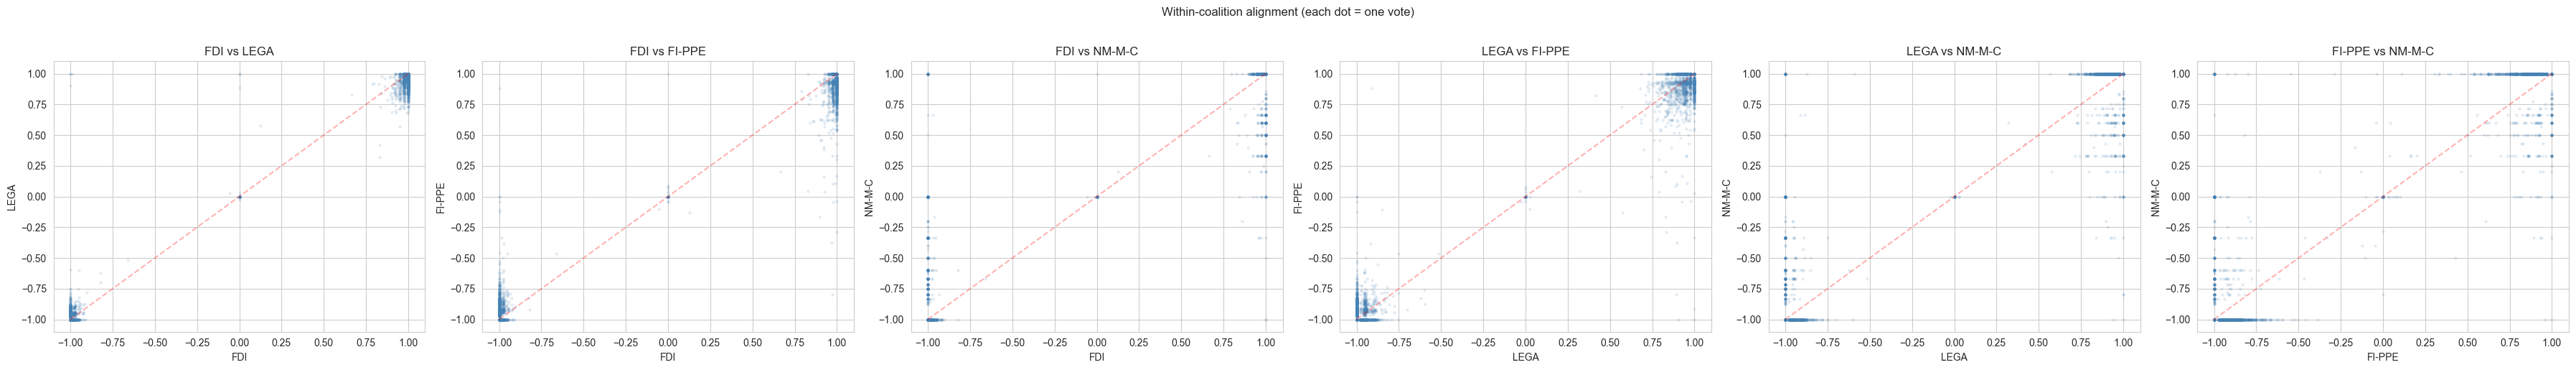

In [ ]:
# Within-coalition alignment
coal_party_avg = (
    df_voted[df_voted['group'].isin(coal_groups)]
    .groupby(['group', 'vote_id'])['vote_code'].mean()
    .unstack(level=0)
)

pairs_to_plot = list(combinations(coal_groups, 2))
fig, axes = plt.subplots(1, len(pairs_to_plot),
                         figsize=(6*len(pairs_to_plot), 5))
if len(pairs_to_plot) == 1:
    axes = [axes]

for ax, (g1, g2) in zip(axes, pairs_to_plot):
    if g1 in coal_party_avg.columns and g2 in coal_party_avg.columns:
        ax.scatter(coal_party_avg[g1], coal_party_avg[g2],
                   alpha=0.1, s=5, color='steelblue')
        ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.3)
        ax.set_xlabel(g1)
        ax.set_ylabel(g2)
        ax.set_title(f'{g1} vs {g2}')

plt.suptitle('Within-coalition alignment (each dot = one vote)', y=1.02)
plt.tight_layout()
plt.show()

In [84]:
print('=' * 60)
print('EXPLORATION COMPLETE')
print('=' * 60)
print()
print('Files in data/processed/:')
for f in sorted(PROCESSED_DIR.iterdir()):
    print(f'  {f.name}: {f.stat().st_size / 1e6:.1f} MB')
print()
print('Next steps:')
print('  1. UMAP/PCA dimensionality reduction on vote matrix')
print('  2. DBSCAN/hierarchical clustering to find factions')
print('  3. Interactive network graph (D3.js / pyvis)')
print('  4. Policy-area tagging from bill descriptions')

EXPLORATION COMPLETE

Files in data/processed/:
  deputies.parquet: 0.0 MB
  similarity_matrix.parquet: 1.8 MB
  vote_matrix.parquet: 11.8 MB
  votes_clean.parquet: 10.3 MB

Next steps:
  1. UMAP/PCA dimensionality reduction on vote matrix
  2. DBSCAN/hierarchical clustering to find factions
  3. Interactive network graph (D3.js / pyvis)
  4. Policy-area tagging from bill descriptions
